# Notebook 2: DEM Co-registration with xDEM

Co-registers all DEMs to SRTM 2000 as reference using the Nuth & Kääb (2011) method implemented in xDEM.

**Inputs** (from Notebook 1):
- `aligned_dems/SRTM_2000_aligned.tif` ← reference
- `aligned_dems/IGM_1954_aligned.tif`
- `aligned_dems/CerroBlanco_2024_aligned.tif`
- `aligned_dems/LasTermas_2024_aligned.tif`
- Glacier shapefiles (DGA 2000 and 2019)
- Stable-ground mask shapefile (`combined_mask_output.shp`)

**Outputs**:
- `coreg_dems/<name>_coreg.tif` ← co-registered DEMs
- `coreg_dems/coregistration_summary.csv`
- `coreg_dems/coregistration_qc.png`

**Reviewer note on stable terrain masking:**  
We use the UNION of 2000 and 2019 glacier outlines as the glacier mask, so terrain that was ice in 1954 but bare by 2000 is not incorrectly treated as stable ground.

In [1]:
# Step 1: Imports and user variables

import os
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
import xdem
import geoutils as gu

print(f"xDEM version: {xdem.__version__}")

# --- USER VARIABLES: update paths as needed ---
aligned_dem_folder = "aligned_dems"        # output from Notebook 1
output_folder      = "coreg_dems"
os.makedirs(output_folder, exist_ok=True)

glacier_2000_path  = "example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2000/Nevados_polygons_DGA2000.shp"
glacier_2019_path  = "example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2019/Nevados_polygons_DGA2019.shp"
stable_ground_path = "combined_mask_output.shp"   # manually digitized stable areas

reference_name = "SRTM_2000"
source_dems = [
    "IGM_1954",
    "CerroBlanco_2024",
    "LasTermas_2024",
]

# Co-registration method: 'nuthkaab' | 'icp' | 'dh_slope'
COREG_METHOD = "nuthkaab"

xDEM version: 0.2.2


In [2]:
# Step 2: Build glacier union mask
# Union of 2000 + 2019 outlines so terrain that was ice in 1954
# but bare by 2000 is not incorrectly treated as stable ground.

print("Building glacier union mask...")
gdf_2000 = gpd.read_file(glacier_2000_path)
gdf_2019 = gpd.read_file(glacier_2019_path)

if gdf_2000.crs != gdf_2019.crs:
    gdf_2019 = gdf_2019.to_crs(gdf_2000.crs)

glacier_union = gpd.GeoDataFrame(
    geometry=[gdf_2000.union_all().union(gdf_2019.union_all())],
    crs=gdf_2000.crs
)
glacier_union_path = os.path.join(output_folder, "glacier_union_mask.shp")
glacier_union.to_file(glacier_union_path)
print(f"  Glacier union mask saved: {glacier_union_path}")

Building glacier union mask...
  Glacier union mask saved: coreg_dems/glacier_union_mask.shp


In [3]:
# Step 3: Load reference DEM

ref_path = os.path.join(aligned_dem_folder, f"{reference_name}_aligned.tif")
print(f"Loading reference DEM: {ref_path}")
reference_dem = xdem.DEM(ref_path)
print(f"  CRS: {reference_dem.crs}  |  Resolution: {reference_dem.res} m")

Loading reference DEM: aligned_dems/SRTM_2000_aligned.tif
  CRS: EPSG:32719  |  Resolution: (30.00000000022571, 30.00000000022562) m


In [4]:
# Step 4: Create stable-terrain inlier masks
#
# Standard mask (IGM, LasTermas): manual stable areas intersected with glacier union
# CerroBlanco mask: ALL non-glacier terrain within CerroBlanco footprint
#   because the manual stable areas only cover 96 pixels within its footprint,
#   which is too few for NuthKaab to converge reliably.

print("Creating stable-terrain inlier masks...")

# Rasterize glacier union onto reference DEM grid (True = glacier pixel)
glacier_mask = gu.Vector(glacier_union_path).create_mask(reference_dem)
glacier_mask_arr = np.array(glacier_mask.data).squeeze().astype(bool)

# Standard mask: manual stable areas minus glacier union
if os.path.exists(stable_ground_path):
    stable_vec  = gu.Vector(stable_ground_path)
    stable_mask = stable_vec.create_mask(reference_dem)
    inlier_mask_standard     = stable_mask & ~glacier_mask
    inlier_mask_standard_arr = np.array(inlier_mask_standard.data).squeeze().astype(bool)
    print("  Standard mask: manual stable areas minus glacier union")
else:
    inlier_mask_standard     = ~glacier_mask
    inlier_mask_standard_arr = ~glacier_mask_arr
    print("  Standard mask: glacier union only (no manual stable areas found)")

# CerroBlanco mask: all non-glacier pixels within its footprint
with rasterio.open(os.path.join(aligned_dem_folder, "CerroBlanco_2024_aligned.tif")) as src:
    cb_arr    = src.read(1).astype(float)
    cb_nodata = src.nodata

cb_arr[cb_arr == cb_nodata] = np.nan
cb_arr[cb_arr > 1e10]       = np.nan
cb_arr[cb_arr < -1e4]       = np.nan
cb_valid = np.isfinite(cb_arr)
inlier_mask_cerro_arr = cb_valid & ~glacier_mask_arr

print(f"  Standard stable pixels (IGM, LasTermas): {inlier_mask_standard_arr.sum():,}")
print(f"  CerroBlanco footprint pixels:            {cb_valid.sum():,}")
print(f"  CerroBlanco stable pixels:               {inlier_mask_cerro_arr.sum():,}")

# Dictionary: dem_name -> (geoutils mask for pipeline.fit, numpy arr for indexing)
inlier_masks = {
    "IGM_1954":         (inlier_mask_standard, inlier_mask_standard_arr),
    "CerroBlanco_2024": (inlier_mask_standard, inlier_mask_cerro_arr),
    "LasTermas_2024":   (inlier_mask_standard, inlier_mask_standard_arr),
}

Creating stable-terrain inlier masks...
  Standard mask: manual stable areas minus glacier union
  Standard stable pixels (IGM, LasTermas): 327
  CerroBlanco footprint pixels:            1,939
  CerroBlanco stable pixels:               1,011


In [5]:
# Step 5: Co-registration pipeline helper

def get_coreg_pipeline(method: str):
    """
    Return an xDEM co-registration pipeline.
    nuthkaab : Nuth & Kääb (2011) — matches original demcoreg workflow
    icp      : Besl & McKay (1992) — 3D point cloud alignment
    dh_slope : vertical bias correction followed by Nuth & Kääb
    """
    if method == "nuthkaab":
        return xdem.coreg.NuthKaab()
    elif method == "icp":
        return xdem.coreg.ICP()
    elif method == "dh_slope":
        return xdem.coreg.BiasCorr() + xdem.coreg.NuthKaab()
    else:
        raise ValueError(f"Unknown co-registration method: {method}")

In [10]:
# Step 6: Co-register each source DEM to the reference

summary_rows = []

for dem_name in source_dems:
    src_path = os.path.join(aligned_dem_folder, f"{dem_name}_aligned.tif")
    out_path = os.path.join(output_folder, f"{dem_name}_coreg.tif")

    inlier_mask_gu, inlier_mask_arr = inlier_masks[dem_name]

    print(f"\n{'='*60}")
    print(f"Co-registering: {dem_name}  →  {reference_name}")
    print(f"  Stable pixels available: {inlier_mask_arr.sum():,}")
    print(f"{'='*60}")

    source_dem = xdem.DEM(src_path)

    # Pre-registration NMAD
    dh_before = np.array((reference_dem - source_dem).data).squeeze().astype(float)
    dh_before[(dh_before > 1e10) | (dh_before < -1e4)] = np.nan
    stable_before = dh_before[inlier_mask_arr]
    nmad_before = gu.stats.nmad(stable_before[np.isfinite(stable_before)])
    print(f"  NMAD before co-registration: {nmad_before:.3f} m")

    # Run co-registration
    pipeline = get_coreg_pipeline(COREG_METHOD)
    pipeline.fit(
        reference_elev     = reference_dem,
        to_be_aligned_elev = source_dem,
        inlier_mask        = inlier_mask_gu,
    )
    dem_coreg = pipeline.apply(source_dem)

    # Post-registration NMAD
    dh_after = np.array((reference_dem - dem_coreg).data).squeeze().astype(float)
    dh_after[(dh_after > 1e10) | (dh_after < -1e4)] = np.nan
    stable_after = dh_after[inlier_mask_arr]
    nmad_after = gu.stats.nmad(stable_after[np.isfinite(stable_after)])
    print(f"  NMAD after  co-registration: {nmad_after:.3f} m")
    print(f"  NMAD improvement: {(nmad_before - nmad_after):.3f} m  "
          f"({(nmad_before - nmad_after) / nmad_before * 100:.1f}%)")

    # Extract shift offsets — nested under outputs/affine in xDEM 0.2.2
    try:
        nk = pipeline if COREG_METHOD == "nuthkaab" else pipeline.pipeline[1]
        affine_out = nk.meta.get("outputs", {}).get("affine", {})
        n_pts      = nk.meta.get("outputs", {}).get("random", {}).get("subsample_final", "?")
        dx = affine_out.get("shift_x", np.nan)
        dy = affine_out.get("shift_y", np.nan)
        dz = affine_out.get("shift_z", np.nan)
    except Exception:
        dx = dy = dz = np.nan
        n_pts = "?"

    print(f"  Estimated shifts — x: {dx:.2f} m, y: {dy:.2f} m, z: {dz:.2f} m")
    print(f"  Points used for fit: {n_pts}")

    # Flag CerroBlanco if shift is implausibly large (>50m horizontal)
    if dem_name == "CerroBlanco_2024" and (abs(dx) > 50 or abs(dy) > 50):
        print(f"  WARNING: Large horizontal shift detected ({dx:.1f}, {dy:.1f} m).")
        print(f"  Co-registration may have diverged. Consider using aligned DEM directly.")
        print(f"  Saving co-registered version but flagging in summary.")
        flag = "diverged_large_shift"
    else:
        flag = "ok"

    dem_coreg.to_file(out_path)
    print(f"  Saved: {out_path}")

    summary_rows.append({
        "DEM":                dem_name,
        "reference":          reference_name,
        "method":             COREG_METHOD,
        "stable_pixels":      int(inlier_mask_arr.sum()),
        "n_pts_fit":          n_pts,
        "shift_x_m":          round(dx, 3) if not np.isnan(dx) else np.nan,
        "shift_y_m":          round(dy, 3) if not np.isnan(dy) else np.nan,
        "shift_z_m":          round(dz, 3) if not np.isnan(dz) else np.nan,
        "NMAD_before_m":      round(nmad_before, 3),
        "NMAD_after_m":       round(nmad_after, 3),
        "NMAD_improvement_m": round(nmad_before - nmad_after, 3),
        "flag":               flag,
    })

# Save summary CSV
summary_df   = pd.DataFrame(summary_rows)
summary_path = os.path.join(output_folder, "coregistration_summary.csv")
summary_df.to_csv(summary_path, index=False)
print(f"\nCo-registration summary saved: {summary_path}")
print(summary_df.to_string(index=False))


Co-registering: IGM_1954  →  SRTM_2000
  Stable pixels available: 327
  NMAD before co-registration: 7.522 m
  NMAD after  co-registration: 7.312 m
  NMAD improvement: 0.210 m  (2.8%)
  Estimated shifts — x: -6.88 m, y: -11.37 m, z: 1.59 m
  Points used for fit: 327
  Saved: coreg_dems/IGM_1954_coreg.tif

Co-registering: CerroBlanco_2024  →  SRTM_2000
  Stable pixels available: 1,011
  NMAD before co-registration: 8.802 m
  NMAD after  co-registration: 35.344 m
  NMAD improvement: -26.542 m  (-301.5%)
  Estimated shifts — x: 108.70 m, y: -18.86 m, z: -43.30 m
  Points used for fit: 96
  Co-registration may have diverged. Consider using aligned DEM directly.
  Saving co-registered version but flagging in summary.
  Saved: coreg_dems/CerroBlanco_2024_coreg.tif

Co-registering: LasTermas_2024  →  SRTM_2000
  Stable pixels available: 327
  NMAD before co-registration: 10.471 m
  NMAD after  co-registration: 10.356 m
  NMAD improvement: 0.114 m  (1.1%)
  Estimated shifts — x: -7.84 m, y: 3

In [11]:
# Step 6b: Diagnostic — inspect shifts for all DEMs
# Run this to verify shifts are physically plausible before proceeding.

print("Shift diagnostic across all DEMs:")
print(f"{'DEM':<25} {'dx (m)':>10} {'dy (m)':>10} {'dz (m)':>10} {'n_pts':>8} {'assessment'}")
print("-" * 75)

for row in summary_rows:
    dx = row["shift_x_m"]
    dy = row["shift_y_m"]
    dz = row["shift_z_m"]
    horiz = np.sqrt(dx**2 + dy**2) if not (np.isnan(dx) or np.isnan(dy)) else np.nan
    
    if np.isnan(horiz):
        assessment = "unknown"
    elif horiz < 30:
        assessment = "plausible"
    elif horiz < 60:
        assessment = "marginal — review QC plot"
    else:
        assessment = "WARNING: likely diverged"

    print(f"{row['DEM']:<25} {dx:>10.2f} {dy:>10.2f} {dz:>10.2f} "
          f"{str(row['n_pts_fit']):>8}  {assessment}")

print("\nNote: horizontal shifts >1-2 pixels (>30-60m at 30m resolution)")
print("suggest co-registration divergence, especially for small-footprint DEMs.")
print("\nFor DEMs flagged as diverged, use the aligned (pre-coreg) DEM instead:")
print("  cp aligned_dems/CerroBlanco_2024_aligned.tif coreg_dems/CerroBlanco_2024_coreg.tif")

Shift diagnostic across all DEMs:
DEM                           dx (m)     dy (m)     dz (m)    n_pts assessment
---------------------------------------------------------------------------
IGM_1954                       -6.88     -11.37       1.59      327  plausible
CerroBlanco_2024              108.70     -18.86     -43.30       96  WARNING: likely diverged
LasTermas_2024                 -7.84       3.20     -32.97      194  plausible

Note: horizontal shifts >1-2 pixels (>30-60m at 30m resolution)
suggest co-registration divergence, especially for small-footprint DEMs.

For DEMs flagged as diverged, use the aligned (pre-coreg) DEM instead:
  cp aligned_dems/CerroBlanco_2024_aligned.tif coreg_dems/CerroBlanco_2024_coreg.tif


Generating QC plots...


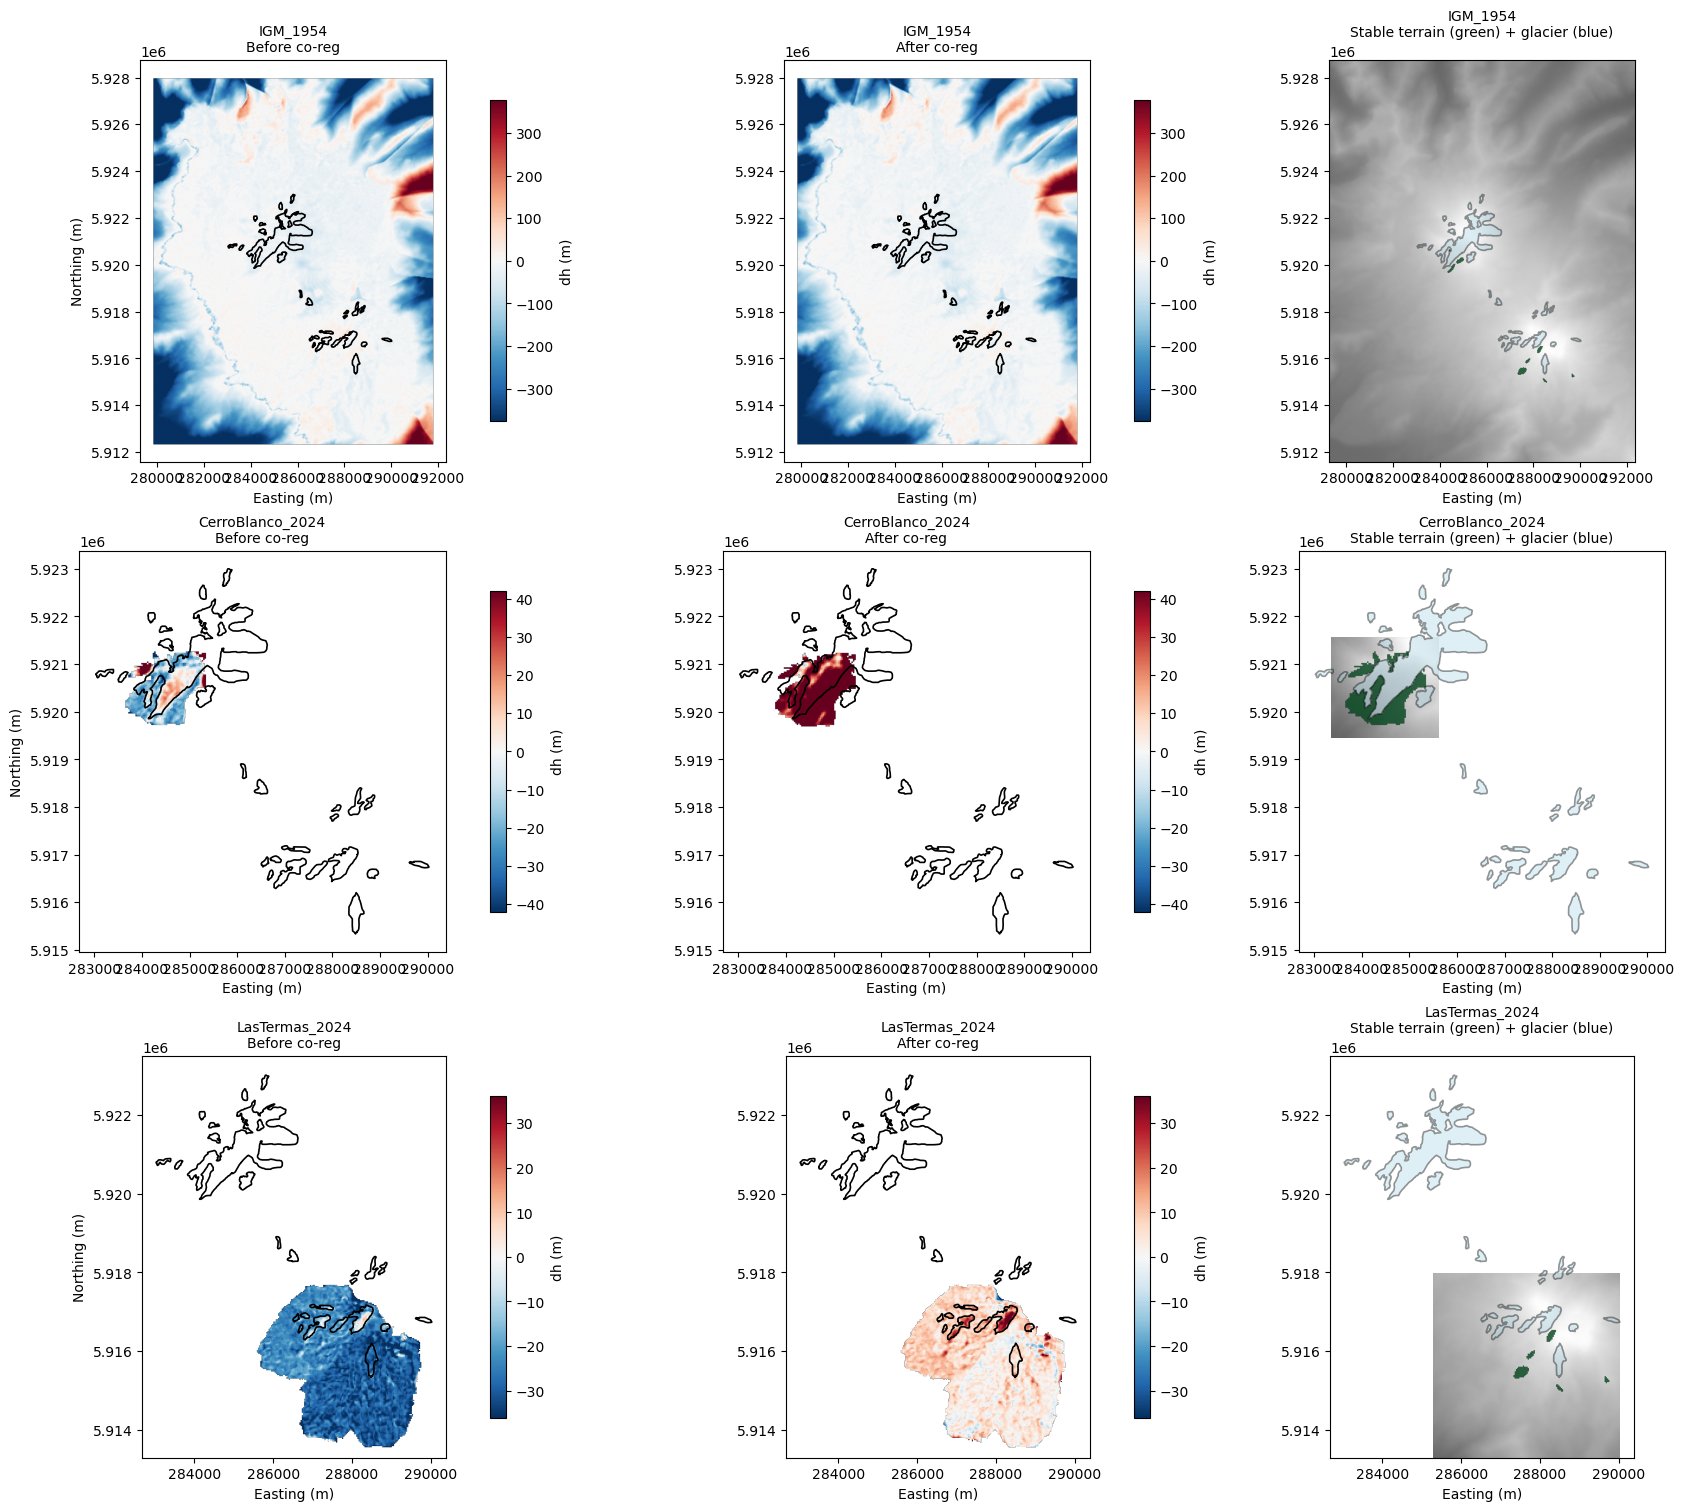

QC plot saved: coreg_dems/coregistration_qc.png


In [12]:
# Step 7: QC plots
# Three columns per DEM:
#   Col 1: full dh before co-registration (with glacier outlines)
#   Col 2: full dh after co-registration (with glacier outlines)
#   Col 3: stable terrain mask location (green) over reference DEM

print("Generating QC plots...")

glacier_union_gdf = gpd.read_file(glacier_union_path)

fig, axes = plt.subplots(
    len(source_dems), 3,
    figsize=(18, 5 * len(source_dems)),
    constrained_layout=True
)
if len(source_dems) == 1:
    axes = [axes]

for i, dem_name in enumerate(source_dems):
    src_path   = os.path.join(aligned_dem_folder, f"{dem_name}_aligned.tif")
    coreg_path = os.path.join(output_folder, f"{dem_name}_coreg.tif")
    _, inlier_mask_arr = inlier_masks[dem_name]

    ref_arr = np.array(reference_dem.data).squeeze().astype(float)
    ref_arr[ref_arr > 1e10] = np.nan
    ref_arr[ref_arr < -1e4] = np.nan

    with rasterio.open(src_path) as src:
        src_arr   = src.read(1).astype(float)
        transform = src.transform
        dem_crs   = src.crs
        bounds    = src.bounds

    with rasterio.open(coreg_path) as src:
        coreg_arr = src.read(1).astype(float)

    for arr in [src_arr, coreg_arr]:
        arr[arr > 1e10] = np.nan
        arr[arr < -1e4] = np.nan

    dh_before = ref_arr - src_arr
    dh_after  = ref_arr - coreg_arr

    # Crop display to valid data extent
    valid_rows, valid_cols = np.where(np.isfinite(dh_before))
    if len(valid_rows) == 0:
        continue
    r0, r1 = valid_rows.min(), valid_rows.max()
    c0, c1 = valid_cols.min(), valid_cols.max()
    pad_r = max(int((r1 - r0) * 0.05), 10)
    pad_c = max(int((c1 - c0) * 0.05), 10)
    r0 = max(r0 - pad_r, 0)
    r1 = min(r1 + pad_r, dh_before.shape[0])
    c0 = max(c0 - pad_c, 0)
    c1 = min(c1 + pad_c, dh_before.shape[1])

    left   = bounds.left + c0 * transform.a
    right  = bounds.left + c1 * transform.a
    top    = bounds.top  + r0 * transform.e
    bottom = bounds.top  + r1 * transform.e
    crop_extent = [left, right, bottom, top]

    finite = dh_before[np.isfinite(dh_before)]
    clim   = float(np.nanpercentile(np.abs(finite), 95)) if len(finite) > 0 else 10.0
    glaciers_reproj = glacier_union_gdf.to_crs(dem_crs)

    # Col 0: dh before
    ax = axes[i][0]
    im = ax.imshow(dh_before[r0:r1, c0:c1], cmap="RdBu_r",
                   vmin=-clim, vmax=clim, extent=crop_extent, origin="upper")
    glaciers_reproj.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.2)
    fig.colorbar(im, ax=ax, shrink=0.8, label="dh (m)")
    ax.set_title(f"{dem_name}\nBefore co-reg", fontsize=10)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")

    # Col 1: dh after
    ax = axes[i][1]
    im = ax.imshow(dh_after[r0:r1, c0:c1], cmap="RdBu_r",
                   vmin=-clim, vmax=clim, extent=crop_extent, origin="upper")
    glaciers_reproj.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.2)
    fig.colorbar(im, ax=ax, shrink=0.8, label="dh (m)")
    ax.set_title(f"{dem_name}\nAfter co-reg", fontsize=10)
    ax.set_xlabel("Easting (m)")

    # Col 2: stable terrain mask
    ax = axes[i][2]
    ref_crop = ref_arr[r0:r1, c0:c1].copy()
    ref_crop[~np.isfinite(ref_crop)] = np.nanmedian(ref_arr[np.isfinite(ref_arr)])
    ax.imshow(ref_crop, cmap="gray", extent=crop_extent, origin="upper", alpha=0.6)
    stable_display = np.where(inlier_mask_arr, 1.0, np.nan)
    ax.imshow(stable_display[r0:r1, c0:c1], cmap="Greens", vmin=0, vmax=1,
              extent=crop_extent, origin="upper", alpha=0.8)
    glaciers_reproj.plot(ax=ax, facecolor="lightblue",
                         edgecolor="black", linewidth=1.2, alpha=0.4)
    ax.set_title(f"{dem_name}\nStable terrain (green) + glacier (blue)", fontsize=10)
    ax.set_xlabel("Easting (m)")

qc_path = os.path.join(output_folder, "coregistration_qc.png")
fig.savefig(qc_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"QC plot saved: {qc_path}")

In [8]:
# Step 8 (Optional): Method comparison
# Uncomment to compare NuthKaab vs ICP vs dh_slope on one DEM.
# Useful for directly responding to the reviewer's suggestion.

# COMPARE_DEM = "IGM_1954"
# src_path = os.path.join(aligned_dem_folder, f"{COMPARE_DEM}_aligned.tif")
# src_dem  = xdem.DEM(src_path)
# inlier_mask_gu, inlier_mask_arr = inlier_masks[COMPARE_DEM]
#
# results = {}
# for method in ["nuthkaab", "icp", "dh_slope"]:
#     pl = get_coreg_pipeline(method)
#     pl.fit(reference_dem, src_dem, inlier_mask=inlier_mask_gu)
#     dem_out = pl.apply(src_dem)
#     dh = np.array((reference_dem - dem_out).data).squeeze().astype(float)
#     dh[(dh > 1e10) | (dh < -1e4)] = np.nan
#     stable = dh[inlier_mask_arr]
#     results[method] = gu.stats.nmad(stable[np.isfinite(stable)])
#     print(f"  {method:12s}  NMAD: {results[method]:.3f} m")
#
# best = min(results, key=results.get)
# print(f"\nLowest post-coreg NMAD: {best} ({results[best]:.3f} m)")

print("Notebook 2 complete. Co-registered DEMs are in:", output_folder)
print("Pass the coreg_dems/ folder to Notebook 3 for differencing and uncertainty analysis.")

Notebook 2 complete. Co-registered DEMs are in: coreg_dems
Pass the coreg_dems/ folder to Notebook 3 for differencing and uncertainty analysis.


In [9]:
# Run this as a standalone diagnostic cell
src_dem = xdem.DEM(os.path.join(aligned_dem_folder, "CerroBlanco_2024_aligned.tif"))
inlier_mask_gu, inlier_mask_arr = inlier_masks["CerroBlanco_2024"]

pipeline = get_coreg_pipeline("nuthkaab")
pipeline.fit(
    reference_elev     = reference_dem,
    to_be_aligned_elev = src_dem,
    inlier_mask        = inlier_mask_gu,
)
print("Pipeline meta keys:", pipeline.meta)
print("Pipeline info:", pipeline._meta)

Pipeline meta keys: {'inputs': {'random': {'subsample': 500000.0, 'random_state': None}, 'fitorbin': {'fit_or_bin': 'bin_and_fit', 'fit_func': <function _nuth_kaab_fit_func at 0x15941a7a0>, 'fit_optimizer': <function curve_fit at 0x13730cca0>, 'bin_sizes': 72, 'bin_statistic': <function nanmedian at 0x10a1611f0>, 'nd': 1, 'bias_var_names': ['aspect']}, 'iterative': {'max_iterations': 10, 'tolerance': 0.001}, 'specific': {}, 'affine': {'apply_vshift': True}}, 'outputs': {'affine': {'shift_x': 108.6990655194823, 'shift_y': -18.855811171989323, 'shift_z': -43.30436846866678}, 'random': {'subsample_final': 96}}}
Pipeline info: {'inputs': {'random': {'subsample': 500000.0, 'random_state': None}, 'fitorbin': {'fit_or_bin': 'bin_and_fit', 'fit_func': <function _nuth_kaab_fit_func at 0x15941a7a0>, 'fit_optimizer': <function curve_fit at 0x13730cca0>, 'bin_sizes': 72, 'bin_statistic': <function nanmedian at 0x10a1611f0>, 'nd': 1, 'bias_var_names': ['aspect']}, 'iterative': {'max_iterations': 10

In [13]:
# Try alternative methods for CerroBlanco
src_dem = xdem.DEM(os.path.join(aligned_dem_folder, "CerroBlanco_2024_aligned.tif"))
inlier_mask_gu, inlier_mask_arr = inlier_masks["CerroBlanco_2024"]

results = {}
for method in ["nuthkaab", "icp", "dh_slope"]:
    pl = get_coreg_pipeline(method)
    pl.fit(reference_dem, src_dem, inlier_mask=inlier_mask_gu)
    dem_out = pl.apply(src_dem)
    
    dh = np.array((reference_dem - dem_out).data).squeeze().astype(float)
    dh[(dh > 1e10) | (dh < -1e4)] = np.nan
    stable = dh[inlier_mask_arr]
    nmad = gu.stats.nmad(stable[np.isfinite(stable)])
    
    affine = pl.meta.get("outputs", {}).get("affine", {})
    dx = affine.get("shift_x", np.nan)
    dy = affine.get("shift_y", np.nan)
    dz = affine.get("shift_z", np.nan)
    n  = pl.meta.get("outputs", {}).get("random", {}).get("subsample_final", "?")
    
    results[method] = nmad
    print(f"{method:12s}  NMAD: {nmad:.3f} m  "
          f"dx: {dx:.2f}  dy: {dy:.2f}  dz: {dz:.2f}  n_pts: {n}")

print(f"\nBest method: {min(results, key=results.get)} "
      f"(NMAD: {min(results.values()):.3f} m)")
print(f"NMAD before any co-reg: 8.802 m")

nuthkaab      NMAD: 35.344 m  dx: 108.70  dy: -18.86  dz: -43.30  n_pts: 96
icp           NMAD: 25.853 m  dx: -16.53  dy: 15.88  dz: -33.05  n_pts: 96


ValueError: No `bias_vars` passed to .fit() for bias correction step <class 'xdem.coreg.biascorr.BiasCorr'> of the pipeline.